# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Skye Tan Ge Hui



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
# Import libraries
import joblib
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly


In [2]:
%matplotlib inline

# 1. Business Understanding
Goal: Use the symptoms of diabeties to gauge if an individual is likely to have diabetes (Classification problem)

# 2. Data Understanding

## 2.1 Load dataset

In [3]:
# Read the diabetes prediction dataset into pandas DataFrame
df = pd.read_csv("diabetes_prediction_dataset.csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


## 2.2 Summary Statistics

In [4]:
# Check duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 3854


In [5]:
# Handle duplicate rows
df = df.drop_duplicates()

In [6]:
# Understand the type of variable for each column (Check data types, Verify number of records, Identify categorical and numerical features)
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  str    
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  str    
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.4 MB


### My Observations
- The dataset contains numerical, categorical and Binary indicator variables
- Numerical features include age, bmi, HbA1c_level and blood_glucose_level
- Categorical features include gender and smoking_history
- Binary indicator features hypertension, heart_disease and diabetes

In [7]:
## Check for missing data
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

### My Observations
- No missing values detected from columns, currently no handling of missing data is required

In [8]:
## Describe data distribution
df.describe(include='all')

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146,96146.000000,96146.000000,96146.000000,96146,96146.000000,96146.000000,96146.000000,96146.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,never,NaN,NaN,NaN,NaN
freq,56161,NaN,NaN,NaN,34398,NaN,NaN,NaN,NaN
mean,NaN,41.794326,0.077601,0.040803,NaN,27.321461,5.532609,138.218231,0.088220
std,NaN,22.462948,0.267544,0.197833,NaN,6.767716,1.073232,40.909771,0.283616
min,NaN,0.080000,0.000000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.000000,0.000000,NaN,23.400000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.000000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,59.000000,0.000000,0.000000,NaN,29.860000,6.200000,159.000000,0.000000


#### My Observations
- HbA1c ranges from 3.5 to 9.0
- Blood glucose ranges from 80 to 300
- BMI ranges from 10.01	to 95.69
- Age ranges from 0.08 to 80
- Gender column has 3 unique variables 
- Smoking history has 6 unique variables
#### My Assumption
- All variables look medically reasonable


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

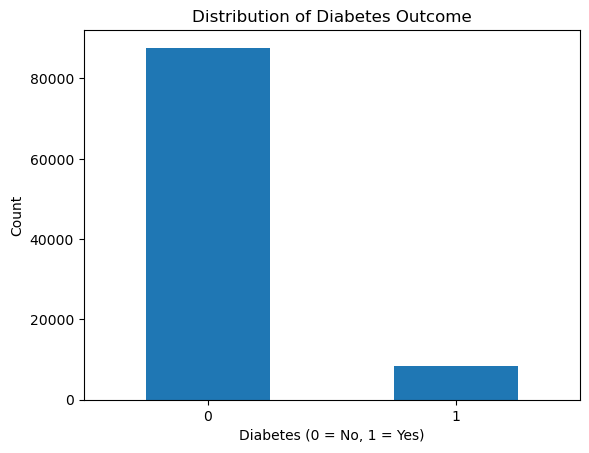

In [9]:
# Plot distribution of target variable (Diabetes)
df['diabetes'].value_counts().plot(kind='bar')

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### My Oberservation
- Dataset is mainly comprised of people with no diabetes

### My Assumptions
- Possible data imbalance, with a lot more non-diabetic than diabetic cases, this may cause the model to favour the majority class
- recall and F1-score is needed to provide a more balanced assessment of model performance

### 2.3.1.2 Understanding distribution of features

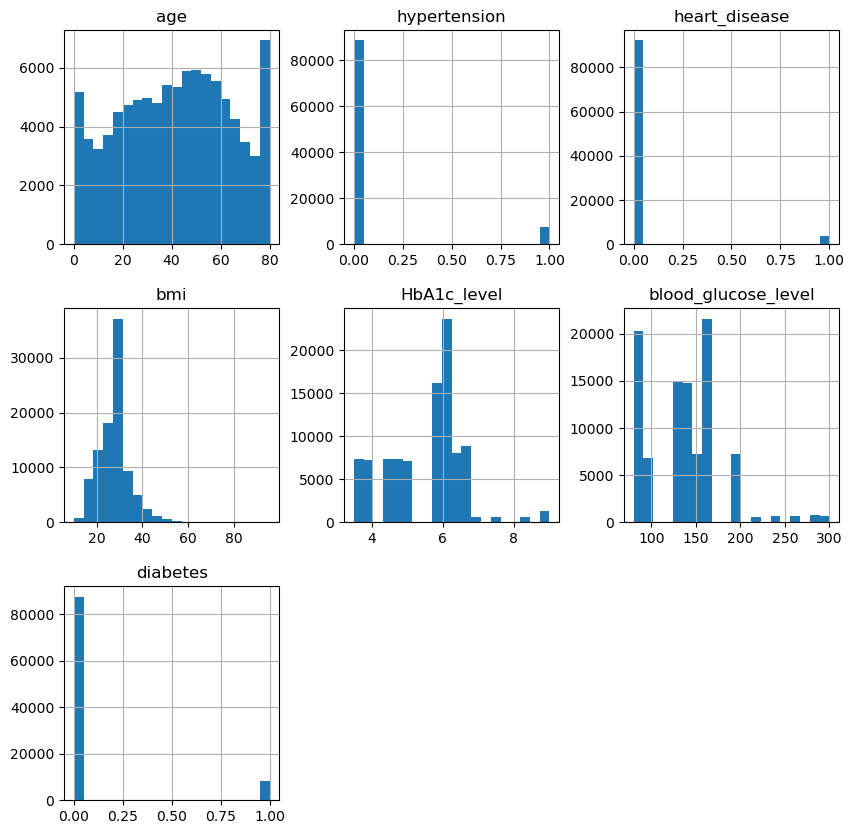

In [10]:
## Understanding distribution of features
## Plot histogram
df.hist(figsize=(10,10), bins=20)
plt.show()

### My Oberservation
- Age is well spread across the dataset
- bmi shows a skewed distribution


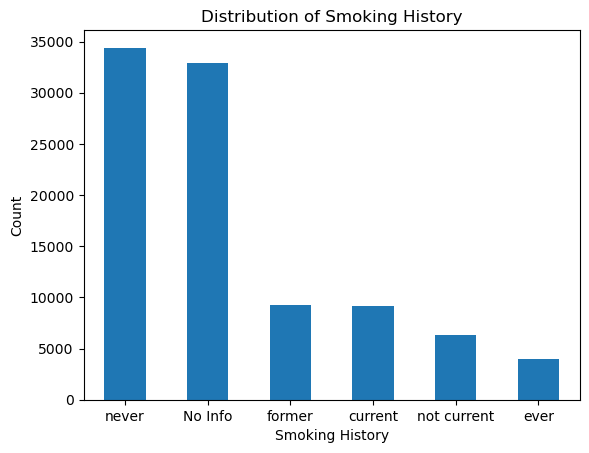

In [11]:
# Plot distribution of smoking_history
df['smoking_history'].value_counts().plot(kind='bar')

plt.title("Distribution of Smoking History")
plt.xlabel("Smoking History")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [12]:
df["smoking_history"].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

### My Observations
- "Never" is the largest smoking category
- Categories "Former", not current" and "Ever" may overlap 
- "No Info" category might not provide value 
### My Assumptions
- Smoking categories may require cleaning

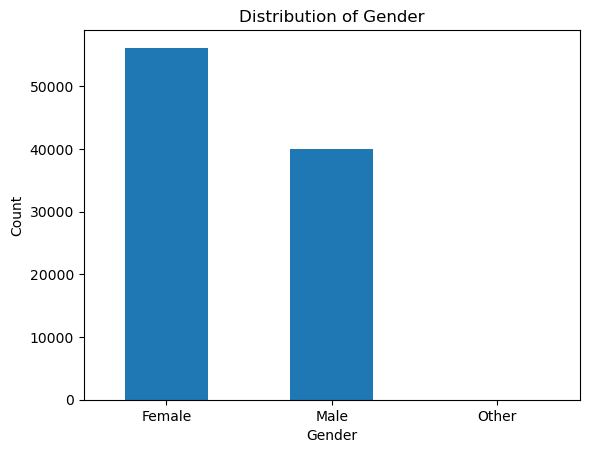

In [13]:
# Plot distribution of target variable (Gender)
df['gender'].value_counts().plot(kind='bar')

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


In [14]:
# Check the count of each gender in the dataset
df["gender"].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

### My Observation
- Female and Male comprise almost all of the rows
- "Other" contains only a very small number of records

### My Assumptions
- Removing "Other" category is unlikely to affect model performance overall because of the small sample size

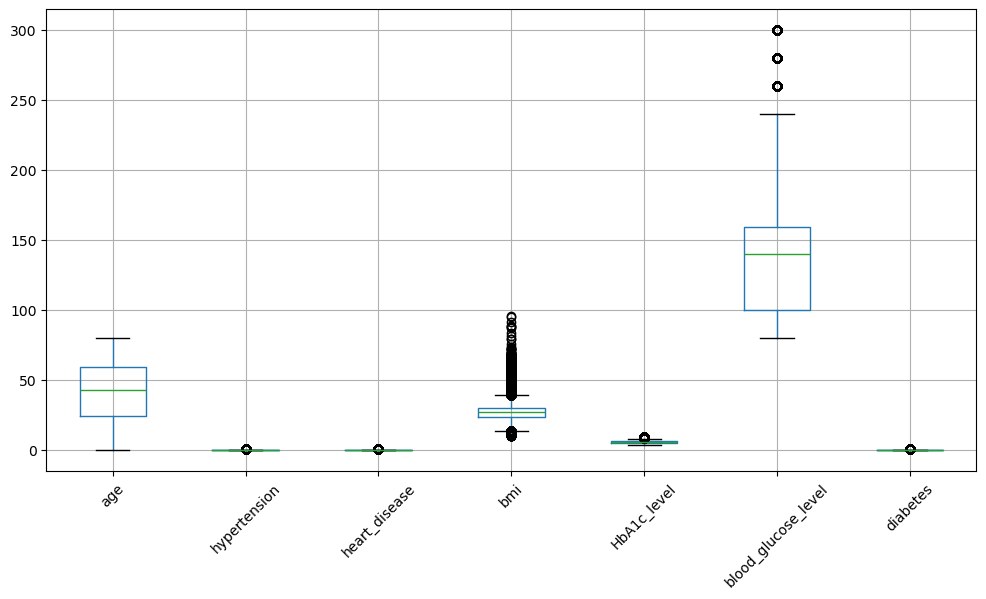

In [15]:
# Plot boxplot for all features to check for outliers
df.boxplot(rot=45, figsize=(12,6)) ## rot: rotation of label
plt.show()


### My Observation
- The boxplot display some outliers for BMI and Blood Glucose Level
### My Assumptions
- The outliers identified are still medically possible and can represent people with obesity, high blood sugar or malnutrition
- (Bmi of 10.01 to 95.69 & Blood Glucose Level of 80 to 300)
- Removing these values could reduce the chance of identifying people with these conditions, so i choose to keep these outliers

### 2.3.2 Understanding relationship between variables

In [16]:
# Select numeric columns (hint: float/int types)
col_numeric = df.select_dtypes(include=['float', 'int']).columns

# Compute correlation matrix (relationship between numeric variables)
df_corr = df[col_numeric].corr()

df_corr

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.257305,0.238451,0.344797,0.106719,0.114317,0.264927
hypertension,0.257305,1.000000,0.119982,0.148111,0.081441,0.084834,0.195710
heart_disease,0.238451,0.119982,1.000000,0.061376,0.068140,0.070832,0.170711
bmi,0.344797,0.148111,0.061376,1.000000,0.084423,0.092543,0.214932
HbA1c_level,0.106719,0.081441,0.068140,0.084423,1.000000,0.171615,0.406408
blood_glucose_level,0.114317,0.084834,0.070832,0.092543,0.171615,1.000000,0.424336
diabetes,0.264927,0.195710,0.170711,0.214932,0.406408,0.424336,1.000000


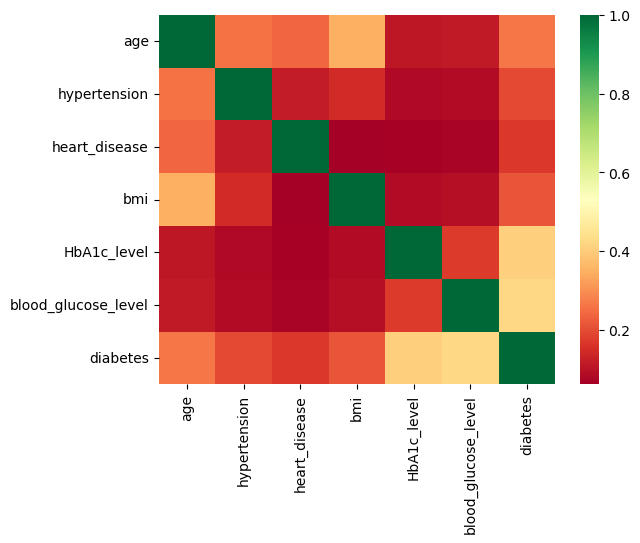

In [17]:
# Visualize correlation matrix using heatmap
sns.heatmap(df_corr, cmap='RdYlGn')
plt.show()


### My Observations
- HbA1c and blood glucose show the strongest correlation with diabetes
- Other variables show weaker correlations
- Blood Glucose > HbA1c Level > age > bmi > hypertension > heart disease
### My Assumptions
- All features have a part to play in predicting diabetes but Blood Glucose and HbA1c Level are the main factors

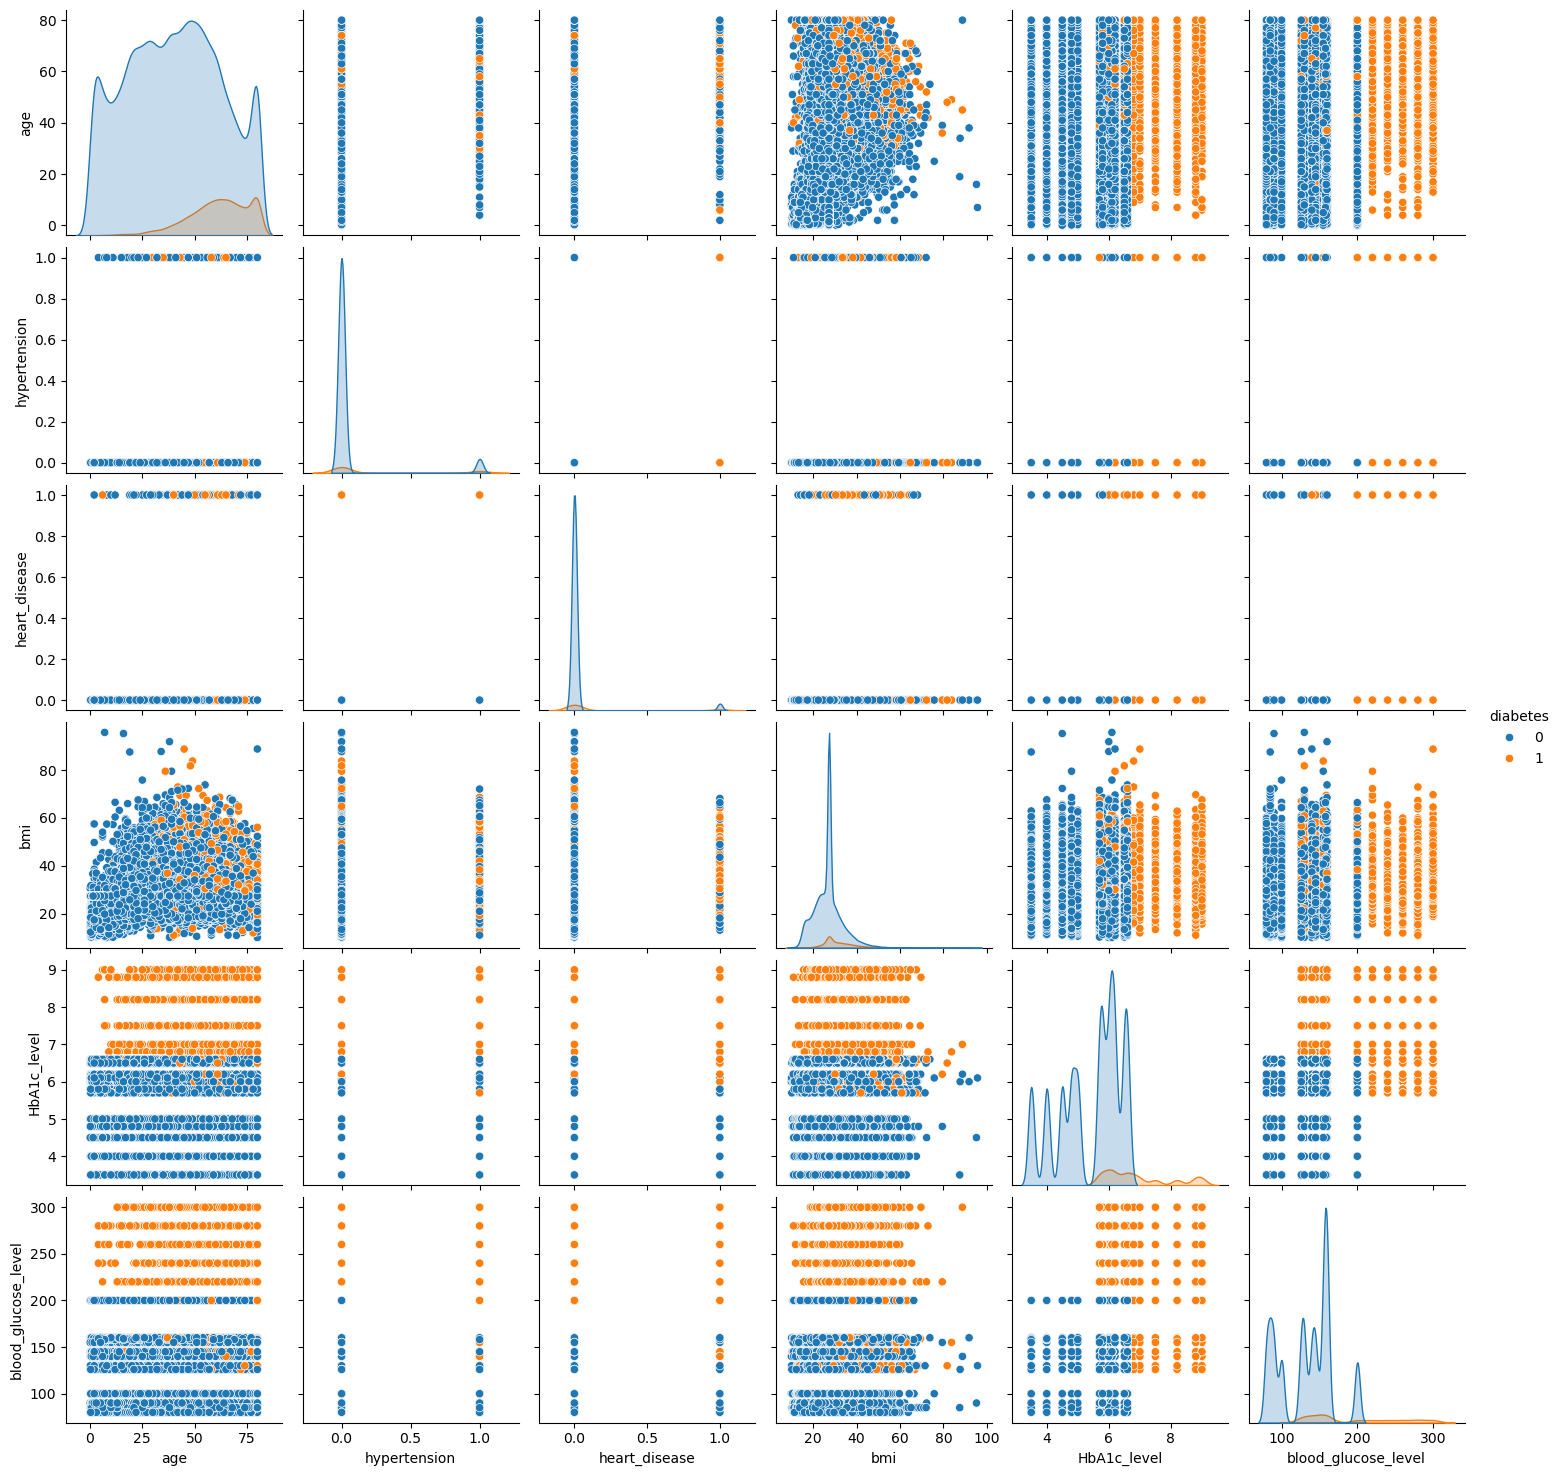

In [18]:
## Understanding relationship between variables and diabetes outcome
## Plot pairplot
sns.pairplot(df, hue='diabetes')
plt.show()

### My Observations
- Diabetic individuals are generally seen with higher blood glucose and HbA1c levels
- Older individuals seem to have a higher appearance of diabetes cases
- More diabetes cases seem to be observed more with individuals of higher BMIs
- Hypertention and Heart Disease shows some separation between the two classes (Individuals observed with the condition have higher chance of having diabetes)
- Most variables show overlap between diabetic and non-diabetic patients, suggesting multiple features are required for accurate prediction
### My Assumptions
- Blood glucose and HbA1c are likely the most important predictors of diabetes
- No one feature can perfectly distinguish diabetic patients, supporting the use of machine learning models combining multiple variables

# 3. Data Preparation

## 3.1 Data Cleaning

In [19]:
## One-Hot Encoding
## Convert categorical variables (gender and smoking_history) into binary columns so machine learning algorithms can process
df = pd.get_dummies(df, columns=['gender','smoking_history'], drop_first=True
)

## Define Features (X) and Target (y)
col_y = "diabetes"
X = df.drop(columns=[col_y])
y = df[col_y]

df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,36.0,0,0,24.60,4.8,145,0,False,False,False,False,False,False,False
99996,2.0,0,0,17.37,6.5,100,0,False,False,False,False,False,False,False
99997,66.0,0,0,27.83,5.7,155,0,True,False,False,False,True,False,False
99998,24.0,0,0,35.42,4.0,100,0,False,False,False,False,False,True,False


## 3.2 Train-Test Split

In [20]:
## Split data into train set and test set
## Separating the data prevents the model from evaluating on data it has seen, providing realistic estimates of model performance 
from sklearn.model_selection import train_test_split

# Split the data (e.g., 70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2026)


# 4. Modelling

### 4.2 Train Model

In [21]:
# Model training
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize model
gbt = GradientBoostingClassifier(random_state=2026)
rf = RandomForestClassifier(n_estimators=100, random_state=2026)
dt = DecisionTreeClassifier(random_state=2026)

# Train model on training data
dt.fit(X_train, y_train)
gbt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Save trained model for later use
import joblib
joblib.dump(dt, "decision_tree_model.pkl")
joblib.dump(gbt, "gradient_boosting_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")


['random_forest_model.pkl']

# 5. Model Evaluation

### Evaluation Criteria

The objective of this project is to identify individuals who may have diabetes based on their health indicators

As a medical indicator, failing to identify a diabetic patient (False Negative) is generally more serious than incorrectly flagging a healthy individual (False Positive). 
Therefore, Recall is an important evaluation metric because it measures how many actual diabetic patients are correctly identified.

However, relying only on Recall may produce many False Positives. Therefore, Precision, F1-score and Accuracy are also evaluated to ensure the model provides a balanced overall performance.

In [22]:
# Model evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predict on test set
y_pred = dt.predict(X_test)
y_pred_gbt = gbt.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluate model performance using classification metrics
for name, preds in [("Decision Tree", y_pred), ("Gradient Boosting", y_pred_gbt), ("Random Forest", y_pred_rf)]:
    print(f"--- {name} ---")
    print(f"  Accuracy:  {accuracy_score(y_test, preds):.4f}")
    print(f"  Precision: {precision_score(y_test, preds):.4f}")
    print(f"  Recall:    {recall_score(y_test, preds):.4f}")
    print(f"  F1 Score:  {f1_score(y_test, preds):.4f}")
    print()

--- Decision Tree ---
  Accuracy:  0.9495
  Precision: 0.6894
  Recall:    0.7490
  F1 Score:  0.7179

--- Gradient Boosting ---
  Accuracy:  0.9727
  Precision: 0.9850
  Recall:    0.6920
  F1 Score:  0.8129

--- Random Forest ---
  Accuracy:  0.9700
  Precision: 0.9389
  Recall:    0.6960
  F1 Score:  0.7994



In [23]:
from sklearn.metrics import classification_report
print("Decision Tree")
print(classification_report(y_test, y_pred))

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gbt))

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     26370
           1       0.69      0.75      0.72      2474

    accuracy                           0.95     28844
   macro avg       0.83      0.86      0.85     28844
weighted avg       0.95      0.95      0.95     28844

Gradient Boosting
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     26370
           1       0.99      0.69      0.81      2474

    accuracy                           0.97     28844
   macro avg       0.98      0.85      0.90     28844
weighted avg       0.97      0.97      0.97     28844

Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     26370
           1       0.94      0.70      0.80      2474

    accuracy                           0.97     28844
   macro avg       0.96      0.85      0.89     28844
weighted avg       0.97     

### My Observations
- Highest Accuracy: Gradient Boosting (0.9727)
- Highest Precision: Gradient Boosting (0.9850)
- Highest Recall: Decision Tree Recall (0.7490)
- Highest F1 Score: Gradient Boosting (0.8129)

### My Analysis
- Gradient Boosting achieved the highest overall accuracy (0.9727), precision (0.9850) and F1-score (0.8129) showing he strongest overall performance
- Decision Tree achieved the highest recall (0.7490), meaning it accuractely identified more diabetic individuals than the other models
- Random Forest produced strong balanced performance being across all metrics but did not outperform Gradient Boosting or Decision Tree in individual metrics
### Business Impact
- Since this project aims to identify potential diabetes cases, Recall is one of the most important because failing to detect diabetic patients could delay further medical assessment
- With this in mind, the model supports Decision Tree as the most suitable model for this version as the Recall was significantly higher than Gradiant Boosting and Random Forest

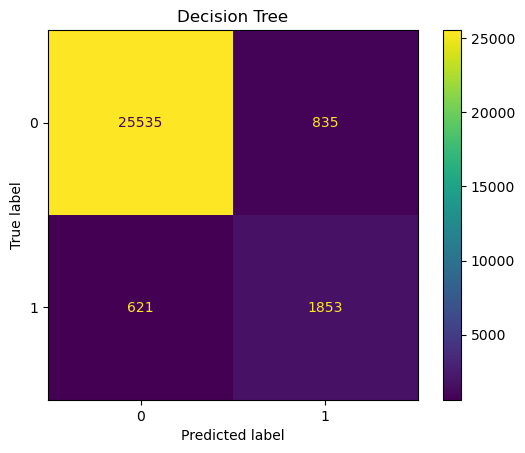

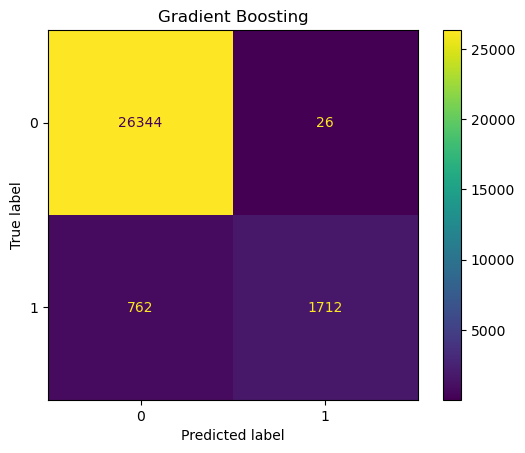

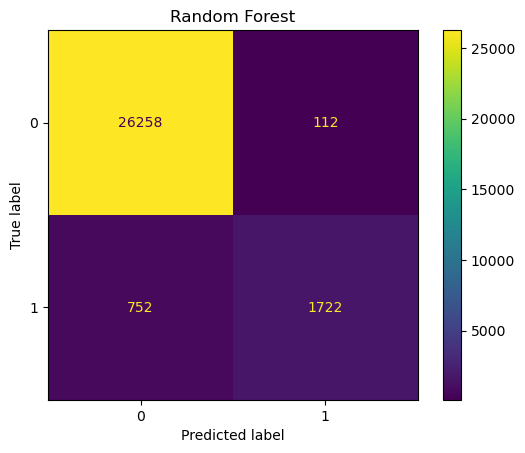

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Decision Tree")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gbt)
plt.title("Gradient Boosting")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest")
plt.show()

### My Observations
- Decision Tree has the least True Negetives (25535), most False Positives (835), least False Negetives (621), most True Positives (1853)
- Gradiant Boosting has the most True Negetives (26344), least False Positives (26), most Flase Negetives (762), least True Positives (1712)
- Random forest has a balance with Decision Tree and Gradient Boosting, True Negetives (26258), False Positives (112), False Negetives (752), True Positives (1722)
### My Analysis 
- Decision Tree is more sensitive wehn predicting diabetic, causing more True Positives but also more False Positives
- Gradient Boosting is more conservative when predicting diabetes, reducing False Positives but increasing False Negatives
- Random Forest provides a compromise between the two approaches without being the best in any individual category
### Business Impact
- False Negatives represent diabetic patients who are incorrectly classified as healthy, reducing False Negatives remains an important objective during model improvement
- The Confusion Matrix supports choosing the Decision Tree as the baseline model for correctly identifying more diabetic patients than the other models|

## Iterative model development


In [25]:
## Further feature engineering / feature selection

## Retrieve feature importance

# After a few more versions

In [26]:
## Retrieve feature importance

# After a few more versions

### My Observations
-
### My Analysis
- 

## Hyperparameter Tuning

In [27]:
# After a few more versions

In [28]:
## Save trained model
#import joblib
joblib.dump(dt,"decision_tree_model.pkl")
## Load trained model
model = joblib.load("decision_tree_model.pkl")


# Development Log

## Version Summary V1 (Base)

Changes:
- Base model

Results:
- Accuracy:  0.9495
- Precision: 0.6894
- Recall:    0.7490
- F1 Score:  0.7179

- Decision Tree True Negetives (25535), False Positives (835), False Negetives (621), True Positives (1853)


Decision:
- Although Gradient Boosting achieved the highest overall accuracy, F1-score and Precision. Missing diabetic patients has greater medical consequences than incorrectly flagging healthy individuals. Hence, the Decision Tree was selected for the baseline as it achieved the highest Recall (0.7490) and least False Negetives (621)